# Прогноз риска задержки доставки CargaPronto

В проекте решается задача для логистической компании CargaPronto: заранее определить, какие заказы имеют высокий риск задержки доставки. По данным внутреннего аудита, значительная доля заказов нарушает SLA, что приводит к штрафам и риску потери крупных клиентов.

Цель исследования — проверить, связаны ли задержки не только с операционными сбоями, но и с профилем клиента: географией, покупательским поведением, частотой заказов, суммой покупок, скидками и долей возвратов. Для этого клиентская база будет сегментирована методами обучения без учителя, а полученные сегменты будут использованы как признаки в модели бинарной классификации.

## Основные гипотезы

1. **География клиента влияет на риск задержки.**  
   Клиенты из отдельных логистических зон могут чаще получать заказы с опозданием из-за сложности маршрутов или удаленности.

2. **Поведенческий профиль клиента связан с задержками.**  
   Частота заказов, давность последней покупки, суммарная выручка, средняя скидка и доля возвратов могут отражать группы клиентов с разным уровнем логистического риска.

3. **Кластеризация клиентов улучшит качество прогноза.**  
   Географические и RFM-сегменты могут дать модели дополнительный контекст и повысить ROC-AUC по сравнению с базовой моделью без кластерных признаков.

4. **Модель может быть полезна для принятия операционных решений.**  
   Если заказ заранее получает высокий риск задержки, логисты могут изменить приоритет сборки, выбрать более быстрый способ доставки, усилить маршрут или заранее уведомить клиента.

## Задача машинного обучения

Необходимо построить модель бинарной классификации, предсказывающую признак `late_delivery_risk`:

- `1` — заказ доставлен с задержкой;
- `0` — заказ доставлен вовремя.

Качество модели будет оцениваться по метрике **ROC-AUC**. Удовлетворительным результатом считается значение выше `0.75`.

В работе будут сравнены базовые модели и модели с дополнительными признаками кластеризации, чтобы оценить, дают ли клиентские сегменты реальную пользу для прогноза риска задержки.

## Аналитический фокус проверки

Бизнес-гипотеза CargaPronto не сводится к вопросу «есть ли задержки»: задержки уже массовые. Важнее понять, можно ли заранее выделить заказы, где риск нарушения SLA управляем через операционные действия: смену приоритета, ускорение доставки, усиление маршрута или проактивное уведомление клиента.

Проверка строится в два слоя:

1. Сначала оценивается, насколько риск объясняется признаками самого заказа: способом доставки, категорией товара, временем оформления и ценой.
2. Затем проверяется, добавляют ли клиентские сегменты новый сигнал: географическая зона, RFM-профиль, скидочная чувствительность и история возвратов.

Если клиентские сегменты дадут прирост ROC-AUC относительно базовой модели, это будет означать, что задержки частично связаны с типом клиента и зоной обслуживания, а не только с текущей загрузкой логистики.


In [1]:
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import (
    GroupShuffleSplit
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    FunctionTransformer
)

from sklearn.impute import SimpleImputer


from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier, Pool

from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay,
    silhouette_score
)


from sklearn.base import BaseEstimator, TransformerMixin


import phik
import optuna
from optuna.samplers import TPESampler
from optuna.visualization import plot_optimization_history

import shap

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

/Users/average/Desktop/учеба/projects/module-5-unsupervised/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Загрузка данных, первичное знакомство

In [2]:
try: 
    customers = pd.read_csv("/datasets/ds_s18_customers.csv")
    orders = pd.read_csv("/datasets/ds_s18_orders.csv")
except FileNotFoundError:
    customers = pd.read_csv("https://code.s3.yandex.net/datasets/ds_s18_customers.csv")
    orders = pd.read_csv("https://code.s3.yandex.net/datasets/ds_s18_orders.csv")

data = {
    "customers": customers,
    "orders": orders
}

for name, df in data.items():
    print(f"{'=' * 10} {name} {'=' * 10}")
    display(pd.concat([df.head(), df.tail(), df.sample(5)]))
    print(df.shape)


========== customers ==========


,customer_id,customer_lat,customer_lon,total_sales,total_orders,avg_discount,return_rate,recency
0,1,25.9536,-97.5077,472.4500,1,0.0600,0.0000,793
1,2,38.3756,-104.7260,1618.6600,4,0.1260,0.0000,137
2,3,18.0254,-66.6151,3189.2000,5,0.1050,0.0000,230
3,4,33.6700,-112.2471,1480.7100,4,0.1350,0.0000,381
4,5,18.3591,-66.0779,1101.9200,3,0.1400,0.0000,458
20647,20753,18.2730,-66.0371,161.8700,1,0.2500,0.0000,1
20648,20754,41.6086,-88.2020,172.6600,1,0.2000,0.0000,1
20649,20755,18.2515,-66.0371,314.6400,1,0.0400,0.0000,1
20650,20756,41.8308,-87.8030,10.9100,1,0.0600,0.0000,1
20651,20757,25.8603,-80.1973,34.9800,1,0.1200,0.0000,1


(20652, 8)
========== orders ==========


,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,order_date,item_price
0,180517,20755,0,Standard Class,Sporting Goods,2018-01-31 22:56:00,327.7500
1,179254,19492,1,Standard Class,Sporting Goods,2018-01-13 12:27:00,327.7500
2,179253,19491,0,Standard Class,Sporting Goods,2018-01-13 12:06:00,327.7500
3,179252,19490,0,Standard Class,Sporting Goods,2018-01-13 11:45:00,327.7500
4,179251,19489,0,Standard Class,Sporting Goods,2018-01-13 11:24:00,327.7500
180514,65177,1005,0,Standard Class,Fishing,2016-01-16 03:40:00,399.9800
180515,65161,9141,1,Second Class,Fishing,2016-01-16 01:34:00,399.9800
180516,65129,291,1,Standard Class,Fishing,2016-01-15 21:00:00,399.9800
180517,65126,2813,0,Standard Class,Fishing,2016-01-15 20:18:00,399.9800
180518,65113,7547,0,Standard Class,Fishing,2016-01-15 18:54:00,399.9800


(180519, 7)


In [3]:
def eda(df):
    eda_cols = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'nulls': df.isna().sum(),
    'null_pct': (df.isna().mean() * 100).round(2),
    'nunique': df.nunique(dropna=True),
    'nunique_pct': (df.nunique(dropna=True) / len(df) * 100).round(2),
    "duplicates": df.duplicated().sum(),
    "duplicates_pct": (df.duplicated().mean() * 100).round(2),
    }).reset_index().rename(columns={'index': 'column'})
    display(eda_cols)
for name, df in data.items():
    print("=" * 100)
    print(name)
    print("=" * 100)
    eda(df)

customers


,column,dtype,nulls,null_pct,nunique,nunique_pct,duplicates,duplicates_pct
0,customer_id,int64,0,0.0000,20652,100.0000,0,0.0000
1,customer_lat,float64,0,0.0000,12767,61.8200,0,0.0000
2,customer_lon,float64,0,0.0000,6161,29.8300,0,0.0000
3,total_sales,float64,0,0.0000,12632,61.1700,0,0.0000
4,total_orders,int64,0,0.0000,15,0.0700,0,0.0000
5,avg_discount,float64,0,0.0000,10600,51.3300,0,0.0000
6,return_rate,float64,0,0.0000,166,0.8000,0,0.0000
7,recency,int64,0,0.0000,1012,4.9000,0,0.0000


orders


,column,dtype,nulls,null_pct,nunique,nunique_pct,duplicates,duplicates_pct
0,order_id,int64,0,0.0000,180519,100.0000,0,0.0000
1,customer_id,int64,0,0.0000,20652,11.4400,0,0.0000
2,late_delivery_risk,int64,0,0.0000,2,0.0000,0,0.0000
3,shipping_mode,str,0,0.0000,4,0.0000,0,0.0000
4,category_name,str,0,0.0000,50,0.0300,0,0.0000
5,order_date,str,0,0.0000,65752,36.4200,0,0.0000
6,item_price,float64,0,0.0000,75,0.0400,0,0.0000


In [4]:
for name, df in data.items():
    print(f"{'=' * 10} {name} {'=' * 10}")
    display(df.describe(include='all').T)

========== customers ==========


,count,mean,std,min,25%,50%,75%,max
customer_id,20652.0000,10400.2859,5993.1062,1.0000,5208.7500,10407.5000,15594.2500,20757.0000
customer_lat,20652.0000,29.7487,9.8241,-33.9376,18.2661,33.2164,39.2922,48.7819
customer_lon,20652.0000,-84.9501,21.2539,-158.0260,-98.4693,-76.7596,-66.3706,115.2631
total_sales,20652.0000,1600.5424,1508.4180,8.4700,254.9400,1294.5050,2621.1400,9436.6101
total_orders,20652.0000,3.1838,2.4307,1.0000,1.0000,3.0000,5.0000,15.0000
avg_discount,20652.0000,0.1017,0.0483,0.0000,0.0762,0.1000,0.1230,0.2500
return_rate,20652.0000,0.0430,0.1566,0.0000,0.0000,0.0000,0.0000,1.0000
recency,20652.0000,221.0891,199.3954,1.0000,76.0000,160.0000,308.0000,1126.0000


========== orders ==========


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,180519.0000,NaN,NaN,NaN,90260.0000,52111.4910,1.0000,45130.5000,90260.0000,135389.5000,180519.0000
customer_id,180519.0000,NaN,NaN,NaN,6691.3795,4162.9181,1.0000,3258.5000,6457.0000,9779.0000,20757.0000
late_delivery_risk,180519.0000,NaN,NaN,NaN,0.5483,0.4977,0.0000,0.0000,1.0000,1.0000,1.0000
shipping_mode,180519,4,Standard Class,107752,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category_name,180519,50,Cleats,24551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_date,180519,65752,2016-10-25 14:39:00,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
item_price,180519.0000,NaN,NaN,NaN,141.2325,139.7325,9.9900,50.0000,59.9900,199.9900,1999.9900


In [5]:
customer_summary = pd.DataFrame({
    "metric": [
        "customers_count",
        "orders_count",
        "one_order_customers_share",
        "median_total_orders",
        "p99_total_orders",
        "median_total_sales",
        "mean_total_sales",
        "p99_total_sales",
    ],
    "value": [
        len(customers),
        len(orders),
        (customers["total_orders"] == 1).mean(),
        customers["total_orders"].median(),
        customers["total_orders"].quantile(0.99),
        customers["total_sales"].median(),
        customers["total_sales"].mean(),
        customers["total_sales"].quantile(0.99),
    ],
})

customer_summary


,metric,value
0,customers_count,20652.0000
1,orders_count,180519.0000
2,one_order_customers_share,0.4302
3,median_total_orders,3.0000
4,p99_total_orders,10.0000
5,median_total_sales,1294.5050
6,mean_total_sales,1600.5424
7,p99_total_sales,5818.8553


### Вывод: качество и структура исходных данных

Данные пригодны для анализа без первичного восстановления: пропусков и полных дублей нет. Объем достаточный для устойчивого сравнения моделей: 20 652 клиента и 180 519 заказов.

Клиентская база неоднородна. 43.02% клиентов сделали только один заказ, медианный клиент сделал 3 заказа, а 99-й процентиль — 10 заказов. Значит, в базе одновременно есть разовые покупатели и небольшая группа более активных клиентов.

По выручке также есть сильная асимметрия: медианная суммарная выручка клиента — 1293.69, средняя — 1599.83, 99-й процентиль — 5817.71. 

In [6]:
orders["customer_id"].isin(customers["customer_id"]).all()

np.True_

In [7]:
orders["order_date"] = pd.to_datetime(orders["order_date"])

orders["order_month"] = orders["order_date"].dt.month
orders["order_weekday_num"] = orders["order_date"].dt.weekday
orders["order_hour"] = orders["order_date"].dt.hour

In [8]:
monthly_risk = (
    orders.groupby("order_month")["late_delivery_risk"]
    .agg(orders_count="count", delay_rate="mean")
    .sort_values("delay_rate", ascending=False)
)

hourly_risk = (
    orders.groupby("order_hour")["late_delivery_risk"]
    .agg(orders_count="count", delay_rate="mean")
    .sort_values("delay_rate", ascending=False)
)

print("Месяцы с максимальным риском задержки:")
display(monthly_risk.head())

print("Месяцы с минимальным риском задержки:")
display(monthly_risk.tail())

print("Часы с максимальным риском задержки:")
display(hourly_risk.head())

print("Часы с минимальным риском задержки:")
display(hourly_risk.tail())


Месяцы с максимальным риском задержки:


,orders_count,delay_rate
order_month,,
8,15912,0.5579
12,12764,0.5534
9,15489,0.5530
3,15919,0.5525
6,15139,0.5483


Месяцы с минимальным риском задержки:


,orders_count,delay_rate
order_month,,
10,12955,0.5460
2,14529,0.5455
11,12500,0.5455
4,15435,0.5428
7,15922,0.5406


Часы с максимальным риском задержки:


,orders_count,delay_rate
order_hour,,
12,7486,0.5950
20,7481,0.5912
22,7418,0.5848
23,7573,0.5806
15,7472,0.5798


Часы с минимальным риском задержки:


,orders_count,delay_rate
order_hour,,
0,7590,0.5148
4,7719,0.5147
11,7497,0.5106
6,7270,0.5095
8,7435,0.5087


### Вывод: временные признаки

Временные признаки нужны не как самостоятельное бизнес-объяснение, а как контроль операционного контекста. По текущим данным месяцы отличаются слабо: риск задержки колеблется примерно от 54.04% в июле до 55.77% в августе. Это не похоже на сильную сезонность

По часу заказа различия заметнее: около 50.73% задержек в 6 утра против 59.62% в 12 часов и 59.25% в 20 часов. Это может отражать нагрузку на складские или диспетчерские процессы в отдельные временные окна


In [9]:
def graphics_numerical(df, column):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(df[column], kde=True, ax=axes[0])
    axes[0].set_title(f'Распределение признака: {column}')
    axes[0].set_xlabel('Значения')
    axes[0].set_ylabel('Количество')

    sns.boxplot(x=df[column], ax=axes[1])
    axes[1].set_title(f'Boxplot: {column}')
    axes[1].set_xlabel('Значения')
    axes[1].set_ylabel('Количество')

    plt.tight_layout()
    plt.show()

def graphics_numerical_cat(df, column):
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=df[column])
    plt.title(F"Распределение признака {column}")
    plt.xlabel("Уникальные значения")
    plt.ylabel("Количество")
    plt.show()

    print(f'Распределение {column}, количество и доля')
    share_target = df[column].value_counts(normalize=True)
    absolut_target = df[column].value_counts(dropna=False)
    target_values = pd.concat([absolut_target, share_target], axis=1)
    target_values.columns = ['Количество', 'Доля']
    display(target_values)

In [10]:
num_cat_o = ["late_delivery_risk", "order_month", "order_weekday_num", "order_hour"]
num_cols_o = ["item_price"]
cat_cols_o = ["shipping_mode", "category_name"]

num_cat_c = ["total_orders"]
num_cols_c = ["total_sales", "avg_discount", "return_rate", "recency"]

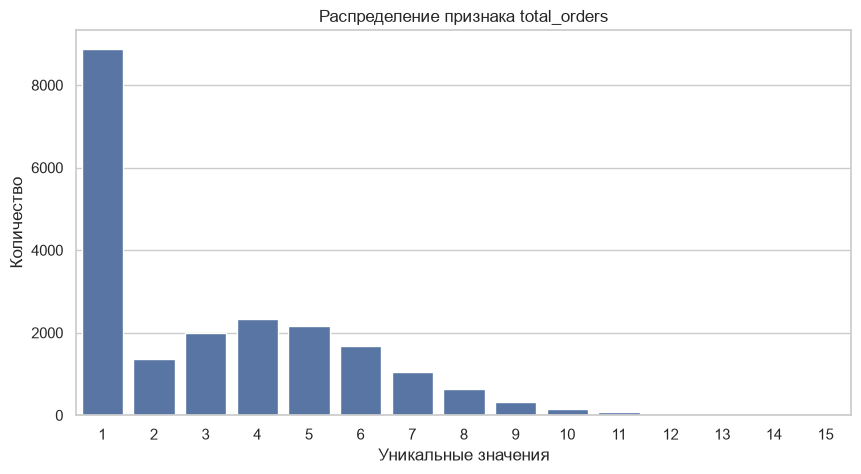

Распределение total_orders, количество и доля


,Количество,Доля
total_orders,,
1,8884,0.4302
4,2324,0.1125
5,2172,0.1052
3,1988,0.0963
6,1668,0.0808
2,1363,0.0660
7,1042,0.0505
8,627,0.0304
9,325,0.0157


In [11]:
graphics_numerical_cat(customers, "total_orders")

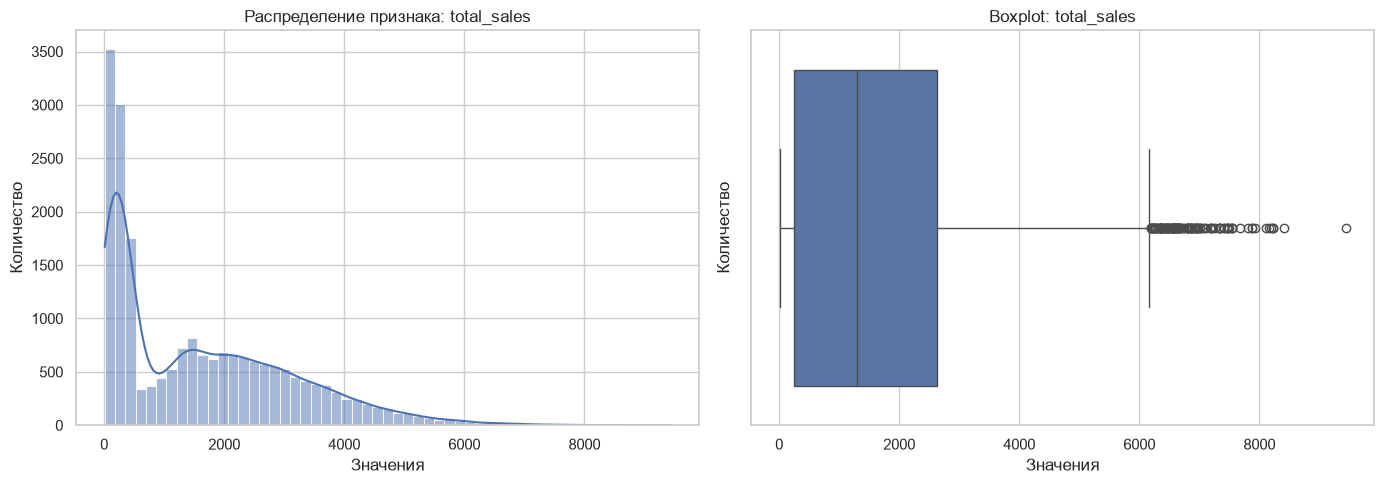

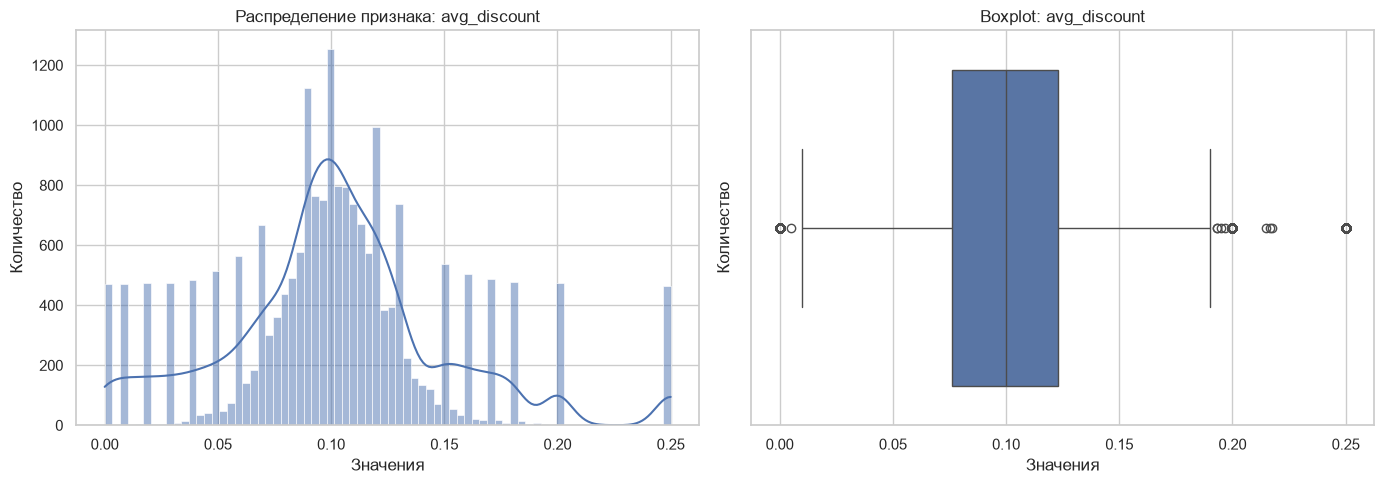

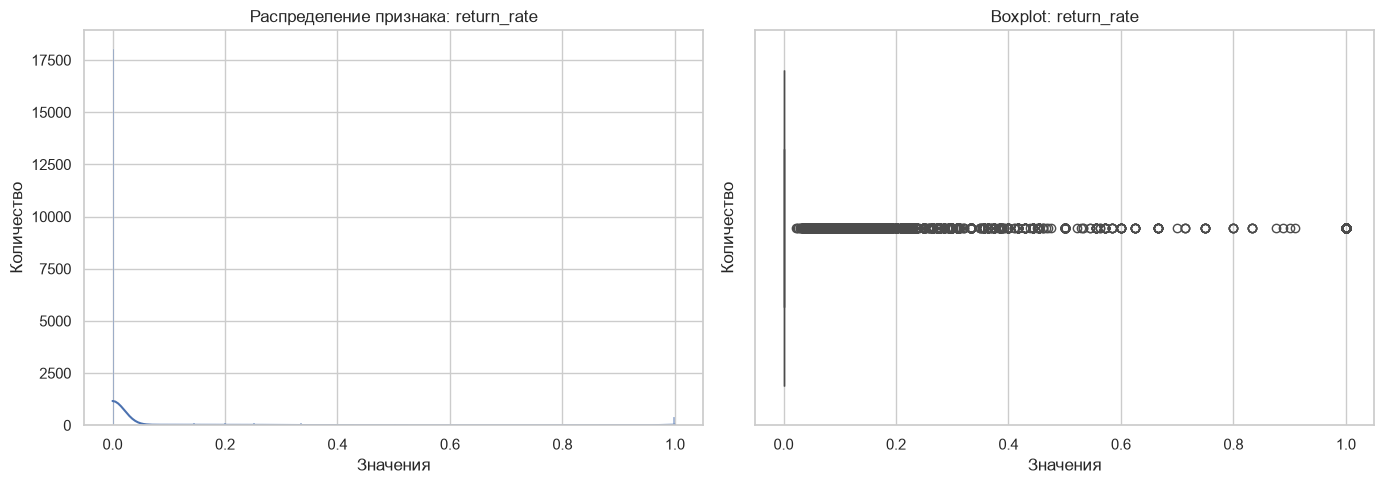

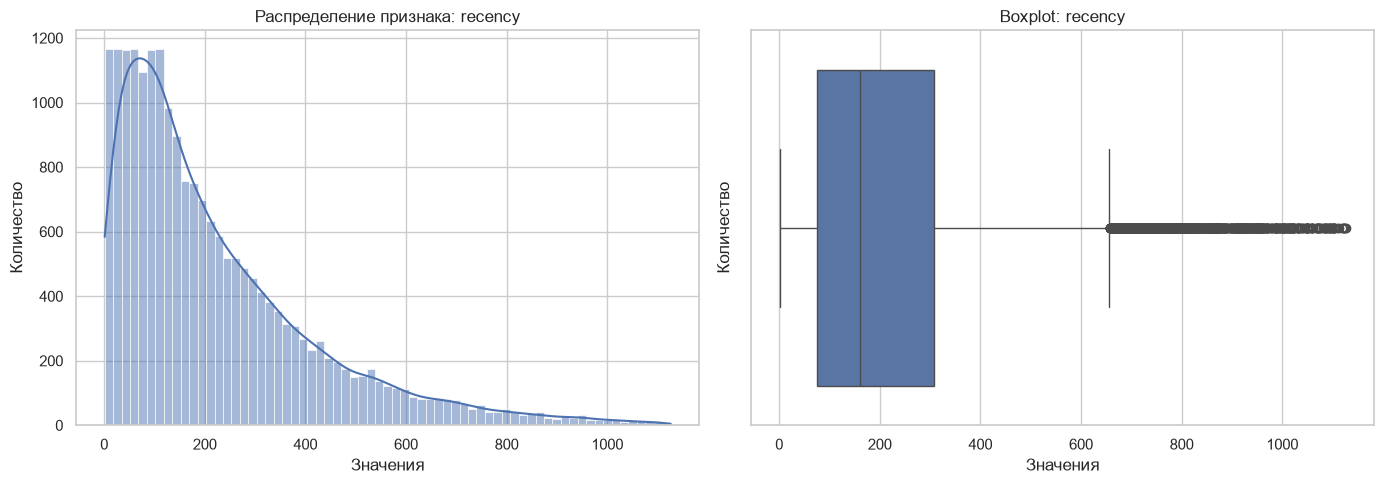

In [12]:
for col in num_cols_c:
    graphics_numerical(customers, col)

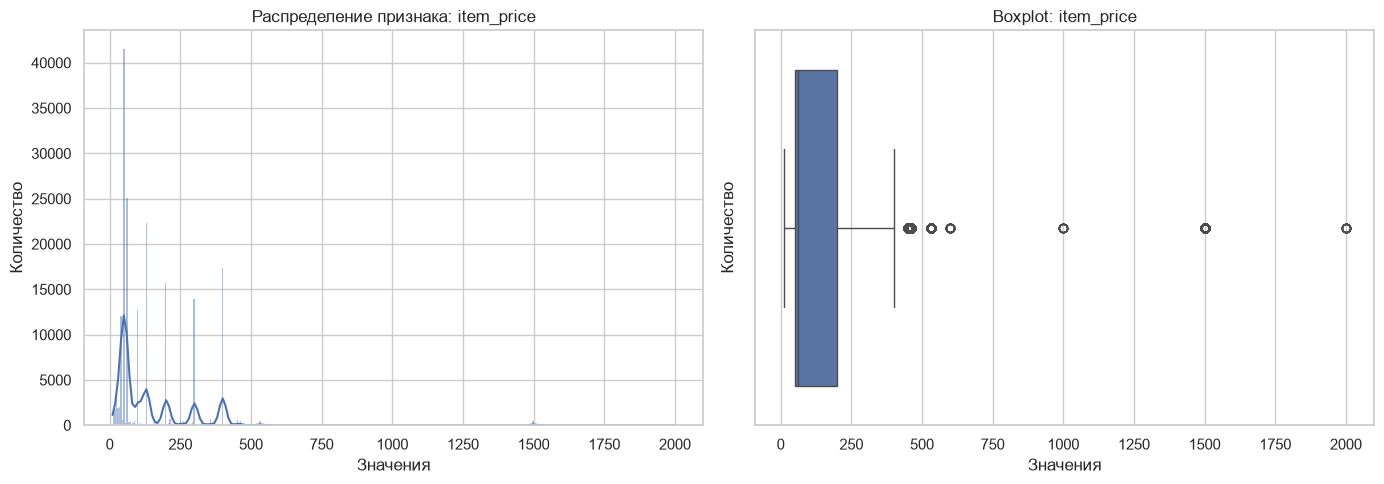

In [13]:
graphics_numerical(orders, "item_price")

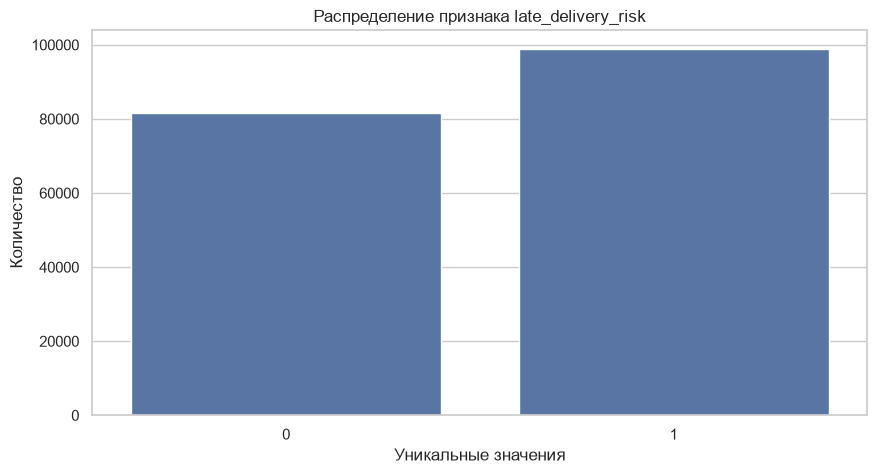

Распределение late_delivery_risk, количество и доля


,Количество,Доля
late_delivery_risk,,
1,98977,0.5483
0,81542,0.4517


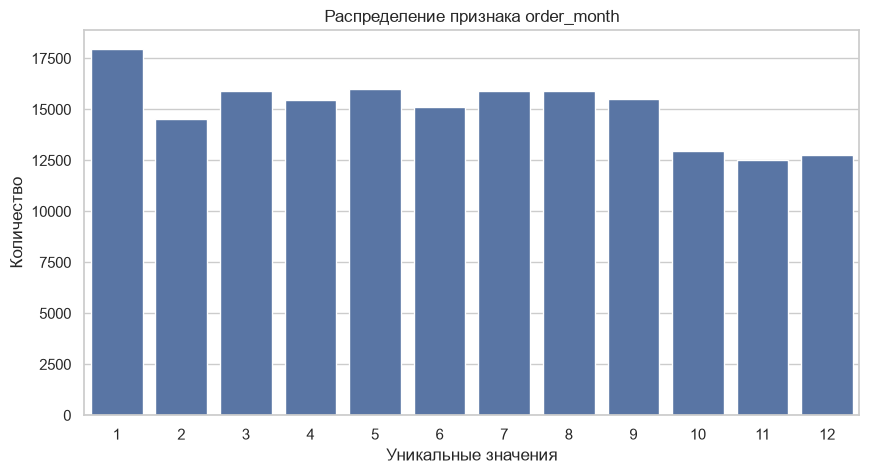

Распределение order_month, количество и доля


,Количество,Доля
order_month,,
1,17979,0.0996
5,15976,0.0885
7,15922,0.0882
3,15919,0.0882
8,15912,0.0881
9,15489,0.0858
4,15435,0.0855
6,15139,0.0839
2,14529,0.0805


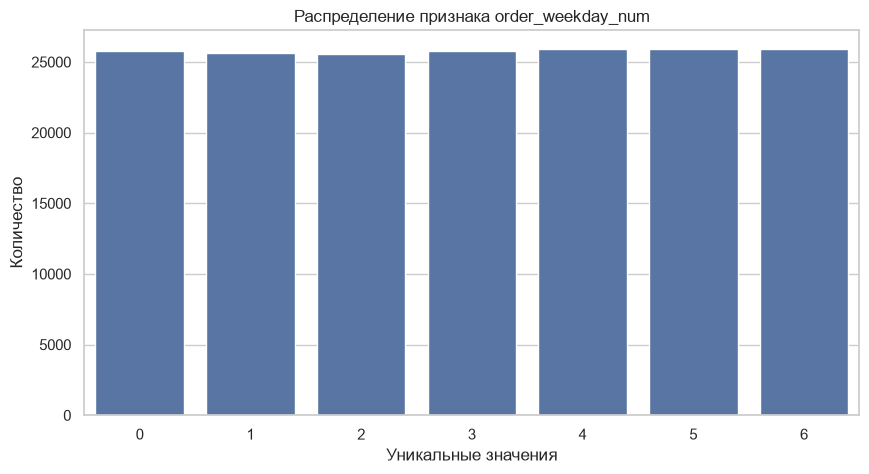

Распределение order_weekday_num, количество и доля


,Количество,Доля
order_weekday_num,,
6,25946,0.1437
4,25925,0.1436
5,25901,0.1435
0,25786,0.1428
3,25752,0.1427
1,25622,0.1419
2,25587,0.1417


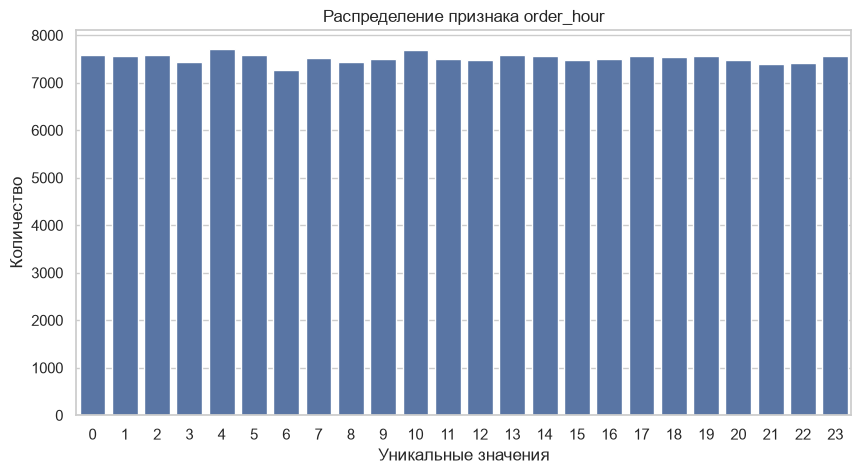

Распределение order_hour, количество и доля


,Количество,Доля
order_hour,,
4,7719,0.0428
10,7697,0.0426
5,7591,0.0421
0,7590,0.0420
13,7578,0.0420
2,7574,0.0420
23,7573,0.0420
17,7573,0.0420
1,7559,0.0419


In [14]:
for col in num_cat_o:
    graphics_numerical_cat(orders, col)

In [15]:
print(orders["shipping_mode"].value_counts(normalize=True))
orders["category_name"].value_counts(normalize=True)

shipping_mode
Standard Class   0.5969
Second Class     0.1951
First Class      0.1541
Same Day         0.0539
Name: proportion, dtype: float64


category_name
Cleats                 0.1360
Men's Footwear         0.1232
Women's Apparel        0.1165
Indoor/Outdoor Games   0.1069
Fishing                0.0960
Water Sports           0.0861
Camping & Hiking       0.0761
Cardio Equipment       0.0692
Shop By Sport          0.0608
Electronics            0.0175
Accessories            0.0099
Golf Balls             0.0082
Girls' Apparel         0.0067
Golf Gloves            0.0059
Trade-In               0.0054
Video Games            0.0046
Children's Clothing    0.0036
Women's Clothing       0.0036
Baseball & Softball    0.0035
Hockey                 0.0034
Cameras                0.0033
Toys                   0.0029
Golf Shoes             0.0029
Pet Supplies           0.0027
Crafts                 0.0027
Garden                 0.0027
DVDs                   0.0027
Computers              0.0024
Golf Apparel           0.0024
Hunting & Shooting     0.0024
Music                  0.0024
Consumer Electronics   0.0024
Boxing & MMA           0.0

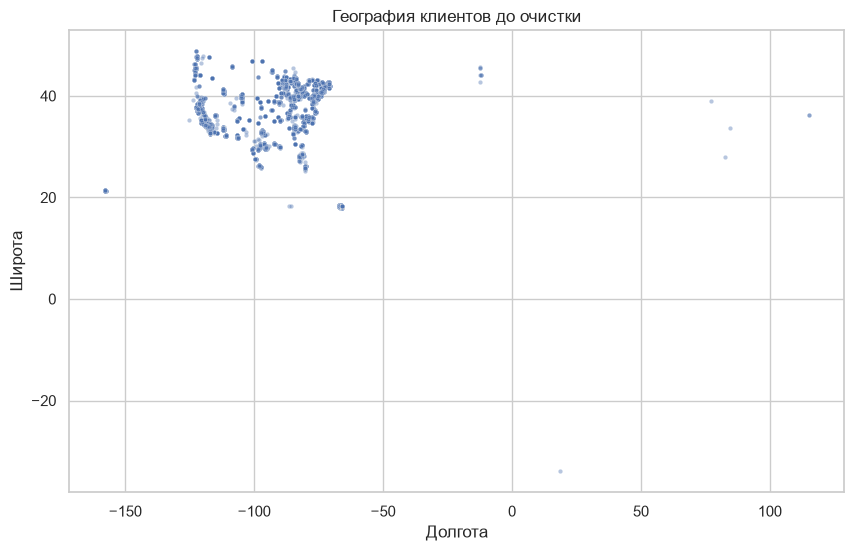

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=customers,
    x="customer_lon",
    y="customer_lat",
    alpha=0.4,
    s=10
)

plt.title("География клиентов до очистки")
plt.xlabel("Долгота")
plt.ylabel("Широта")
plt.grid(True)
plt.show()

Клиентов до: 20652
Клиентов после: 20496
Удалено клиентов: 156
Заказов до: 180519
Заказов после: 179089
Удалено заказов: 1430


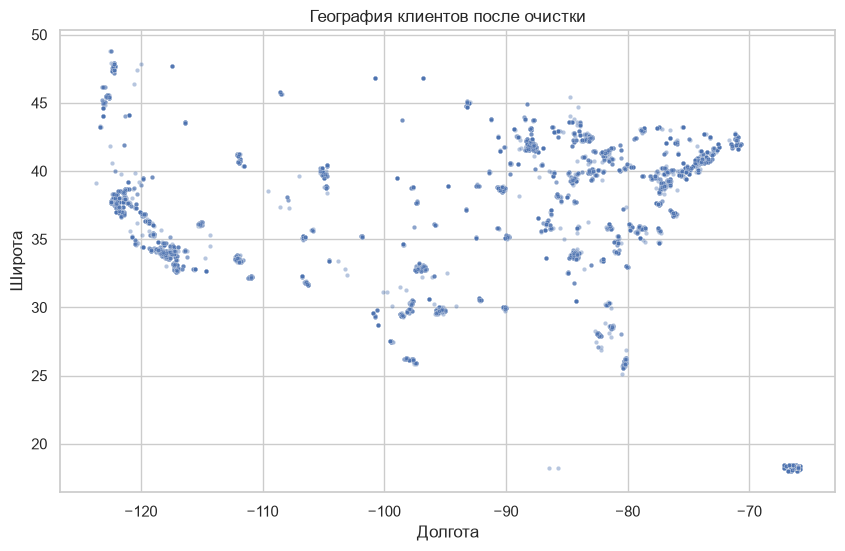

In [17]:
lon_mask = customers["customer_lon"].between(-125, -20)

bad_customer_ids = customers.loc[~lon_mask, "customer_id"]

customers_clean = customers.loc[lon_mask].copy()
orders_clean = orders.loc[
    orders["customer_id"].isin(customers_clean["customer_id"])
].copy()

print("Клиентов до:", len(customers))
print("Клиентов после:", len(customers_clean))
print("Удалено клиентов:", len(bad_customer_ids))

print("Заказов до:", len(orders))
print("Заказов после:", len(orders_clean))
print("Удалено заказов:", len(orders) - len(orders_clean))

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=customers_clean,
    x="customer_lon",
    y="customer_lat",
    alpha=0.4,
    s=10
)

plt.title("География клиентов после очистки")
plt.xlabel("Долгота")
plt.ylabel("Широта")
plt.grid(True)
plt.show()

### Вывод: географические выбросы

Найдено 156 клиентов с долготой вне допустимого диапазона `[-125, -20]`; вместе с ними удалено 1430 заказов. Это около 0.76% клиентской базы, то есть очистка почти не меняет общий объем данных, но критична для кластеризации.


In [18]:
customer_distribution = pd.DataFrame({
    "metric": [
        "share_one_order_customers",
        "p75_total_orders",
        "median_recency",
        "p75_recency",
        "p95_recency",
        "share_zero_return_rate",
        "share_positive_return_rate",
    ],
    "value": [
        (customers_clean["total_orders"] == 1).mean(),
        customers_clean["total_orders"].quantile(0.75),
        customers_clean["recency"].median(),
        customers_clean["recency"].quantile(0.75),
        customers_clean["recency"].quantile(0.95),
        (customers_clean["return_rate"] == 0).mean(),
        (customers_clean["return_rate"] > 0).mean(),
    ],
})

orders_with_customers = orders_clean.merge(customers_clean, on="customer_id", how="left")
orders_with_customers["recency_bin"] = pd.cut(
    orders_with_customers["recency"],
    [0, 30, 90, 180, 365, 2000],
    labels=["<=30", "31-90", "91-180", "181-365", ">365"],
)

recency_risk = (
    orders_with_customers.groupby("recency_bin", observed=True)["late_delivery_risk"]
    .agg(orders_count="count", delay_rate="mean")
)

display(customer_distribution)
display(recency_risk)


,metric,value
0,share_one_order_customers,0.4304
1,p75_total_orders,5.0000
2,median_recency,160.0000
3,p75_recency,308.0000
4,p95_recency,640.2500
5,share_zero_return_rate,0.8728
6,share_positive_return_rate,0.1272


,orders_count,delay_rate
recency_bin,,
<=30,2041,0.5600
31-90,4080,0.5520
91-180,50069,0.5475
181-365,81208,0.5502
>365,41691,0.5447


### Вывод: структура клиентской базы

Большая часть клиентов имеет короткую историю взаимодействия: 43.02% сделали один заказ, 75% клиентов имеют не больше 5 заказов. Это ограничивает надежность персонального профиля для каждого отдельного клиента

`recency` также распределен неравномерно: медиана — 160 дней, 75-й процентиль — 308 дней, 95-й процентиль — 640 дней. В базе много клиентов, которые давно не заказывали. Однако риск задержки по группам recency меняется слабо: примерно 54.47-56.00%. Значит, давность последнего заказа сама по себе не выглядит главным фактором задержки

In [19]:
target_rate = orders_clean["late_delivery_risk"].mean()

shipping_risk = (
    orders_clean.groupby("shipping_mode")["late_delivery_risk"]
    .agg(orders_count="count", delay_rate="mean")
    .sort_values("delay_rate", ascending=False)
)

category_risk = (
    orders_clean.groupby("category_name")["late_delivery_risk"]
    .agg(orders_count="count", delay_rate="mean")
    .query("orders_count >= 1000")
    .sort_values("delay_rate", ascending=False)
)

print(f"Доля задержек после геоочистки: {target_rate:.2%}")
print("Риск задержки по режиму доставки:")
display(shipping_risk)
print("Категории с максимальным риском среди категорий с 1000+ заказов:")
display(category_risk.head(12))


Доля задержек после геоочистки: 54.83%
Риск задержки по режиму доставки:


,orders_count,delay_rate
shipping_mode,,
First Class,27582,0.9536
Second Class,34946,0.7667
Same Day,9691,0.4559
Standard Class,106870,0.3807


Категории с максимальным риском среди категорий с 1000+ заказов:


,orders_count,delay_rate
category_name,,
Accessories,1766,0.5713
Golf Gloves,1056,0.5634
Electronics,3135,0.5598
Girls' Apparel,1188,0.5530
Shop By Sport,10891,0.5516
Cleats,24374,0.5497
Fishing,17187,0.5490
Water Sports,15421,0.5481
Indoor/Outdoor Games,19149,0.5474


### Вывод: структура заказов и целевой переменной

Главный обнаруженный операционный сигнал — `shipping_mode`. Распределение риска резко отличается по режимам: `First Class` задерживается в 95.36% случаев, `Second Class` — в 76.67%, `Same Day` — в 45.59%, `Standard Class` — в 38.07%. Это контринтуитивно: более быстрые классы не выглядят более надежными. Возможная бизнес-интерпретация - быстрый режим выбирается или назначается для изначально сложных, срочных или рискованных заказов, либо SLA для таких режимов жестче


interval columns not set, guessing: ['late_delivery_risk', 'item_price', 'order_month', 'order_weekday_num', 'order_hour']


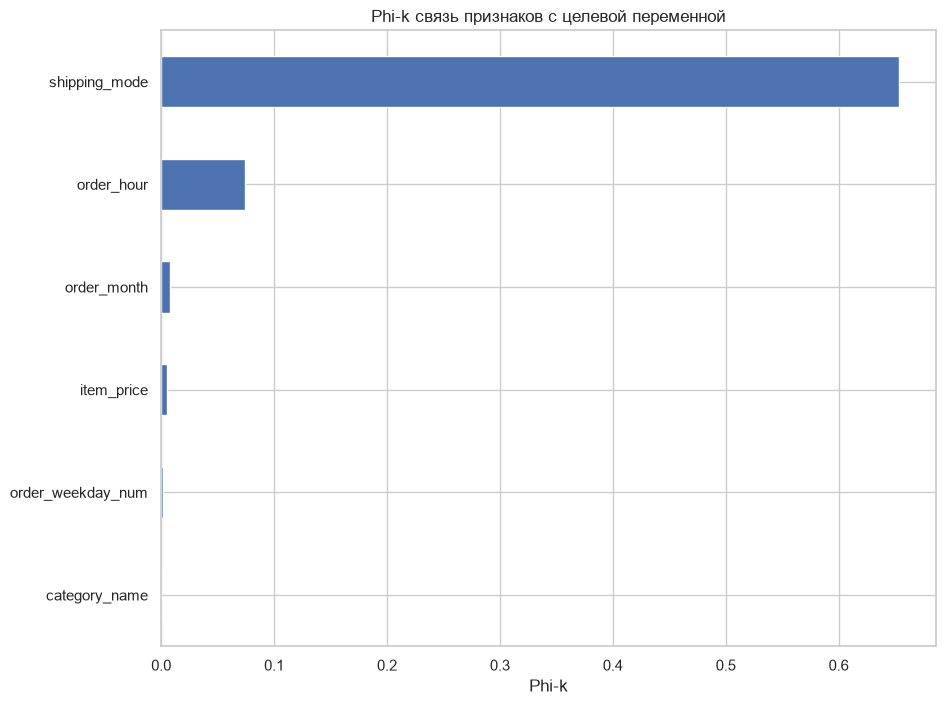

,phik_with_target
shipping_mode,0.6537
order_hour,0.0745
order_month,0.0081
item_price,0.0048
order_weekday_num,0.0017
category_name,0.0000


In [20]:
target = "late_delivery_risk"
phik_data = orders_clean.drop(columns=["order_id", "customer_id", "order_date"]).copy()

phik_corr = phik_data.phik_matrix()

target_phik = (
    phik_corr[target]
    .drop(target)
    .sort_values(ascending=False)
)

target_phik.sort_values().plot.barh(figsize=(10, 8))
plt.title("Phi-k связь признаков с целевой переменной")
plt.xlabel("Phi-k")
plt.show()

display(target_phik.to_frame("phik_with_target"))

In [21]:
orders_with_customers = orders_clean.merge(customers_clean, on="customer_id", how="left")
orders_with_customers["return_rate_bin"] = pd.cut(
    orders_with_customers["return_rate"],
    [-0.001, 0, 0.25, 0.5, 0.75, 1],
    labels=["0", "0-25%", "25-50%", "50-75%", "75-100%"],
)

return_rate_risk = (
    orders_with_customers.groupby("return_rate_bin", observed=True)["late_delivery_risk"]
    .agg(orders_count="count", delay_rate="mean")
)

display(target_phik.to_frame("phik_with_target"))
display(return_rate_risk)


,phik_with_target
shipping_mode,0.6537
order_hour,0.0745
order_month,0.0081
item_price,0.0048
order_weekday_num,0.0017
category_name,0.0000


,orders_count,delay_rate
return_rate_bin,,
0,141139,0.5708
0-25%,29024,0.5007
25-50%,7766,0.3793
50-75%,620,0.2548
75-100%,540,0.0074


### Вывод: первичная проверка гипотез по phi-k

`shipping_mode` имеет самую сильную связь с задержкой (`phi-k = 0.6537`). Это значит, что базовая модель, скорее всего, уже получит существенный сигнал из режима доставки

Остальные признаки заказа почти не объясняют риск: `order_hour` дает слабый сигнал (`0.0745`), месяц, день недели, цена и категория товара близки к нулю


In [22]:
groups = orders_clean["customer_id"]
gss = GroupShuffleSplit(n_splits=1, train_size=0.6, random_state=RANDOM_STATE)

train_idx, tmp_idx = next(gss.split(orders_clean, groups=groups))

df_train = orders_clean.iloc[train_idx].copy()
df_tmp = orders_clean.iloc[tmp_idx].copy()

gss_2 = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=RANDOM_STATE)
val_idx, test_idx = next(gss_2.split(df_tmp, groups=df_tmp["customer_id"]))
df_val = df_tmp.iloc[val_idx].copy()
df_test = df_tmp.iloc[test_idx].copy()



In [23]:
train_customers = set(df_train["customer_id"])
val_customers = set(df_val["customer_id"])
test_customers = set(df_test["customer_id"])

print("train:", len(df_train))
print("val:", len(df_val))
print("test:", len(df_test))

print("train in val:", len(train_customers & val_customers))
print("train in test:", len(train_customers & test_customers))
print("val in test:", len(val_customers & test_customers))

train: 107721
val: 35355
test: 36013
train in val: 0
train in test: 0
val in test: 0


In [24]:
baseline_columns = ["shipping_mode", "category_name", "item_price", "order_month", "order_weekday_num", "order_hour"]

df_train_baseline = df_train[baseline_columns + [target]].copy()
df_val_baseline = df_val[baseline_columns + [target]].copy()

In [25]:
X_train_base = df_train_baseline.drop(columns=[target])
y_train_base = df_train_baseline[target]
X_val_base = df_val_baseline.drop(columns=[target])
y_val_base = df_val_baseline[target]

In [26]:
def evaluate_models(pipelines, X_train, X_val, y_train, y_val):
    scores = {}
    fitted_models = {}

    for model_name, pipe in pipelines.items():
        model = pipe.fit(X_train, y_train)

        y_pred = model.predict(X_val)
        y_proba = model.predict_proba(X_val)[:, 1]

        scores[model_name] = {
            "accuracy": accuracy_score(y_val, y_pred),
            "precision": precision_score(y_val, y_pred),
            "recall": recall_score(y_val, y_pred),
            "f1": f1_score(y_val, y_pred),
            "roc_auc": roc_auc_score(y_val, y_proba),
        }

        fitted_models[model_name] = model

    scores_df = (
        pd.DataFrame(scores)
        .T
        .sort_values(by="roc_auc", ascending=False)
    )

    display(scores_df.round(4))

    return scores_df, fitted_models

In [27]:
num_cols_baseline = ["item_price", "order_month", "order_weekday_num", "order_hour"]
cat_cols_baseline = ["shipping_mode", "category_name"]

In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols_baseline),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols_baseline)
    ],
    remainder="drop"
)

pipe_logistic_baseline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

cat_base = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    cat_features=tuple(cat_cols_baseline),
    verbose=0,
    random_seed=RANDOM_STATE,
)

pipes = {
    "Logistic Regression": pipe_logistic_baseline,
    "CatBoost": cat_base
}

In [29]:
score, models = evaluate_models(pipes, X_train_base, X_val_base, y_train_base, y_val_base)

,accuracy,precision,recall,f1,roc_auc
CatBoost,0.7207,0.8550,0.5928,0.7002,0.7569
Logistic Regression,0.7027,0.8549,0.5536,0.6720,0.7343


### Вывод: базовая модель

На базовых признаках заказа CatBoost показал ROC-AUC = 0.7569 и уже превысил целевой порог 0.75. Логистическая регрессия получила ROC-AUC = 0.7343 и не достигла целевого уровня.

Это значит, что значимая часть риска задержки уже объясняется параметрами самого заказа, прежде всего режимом доставки.

In [30]:
train_customer_ids = set(df_train["customer_id"])
df_train_customers = customers_clean.loc[
    customers_clean["customer_id"].isin(train_customer_ids)
].copy()

assert set(df_train_customers["customer_id"]) == train_customer_ids


In [31]:
geo_features = ["customer_lat", "customer_lon"]
geo_scaler = StandardScaler()
X_geo_train = df_train_customers[geo_features]
X_geo_train_scaled = geo_scaler.fit_transform(X_geo_train)


In [32]:
K_VALUES = range(2, 12)

def evaluate_clusters(X_scaled):
    rows = []

    for k in K_VALUES:
        model = KMeans(
            n_clusters=k,
            init="k-means++",
            n_init=10,
            random_state=RANDOM_STATE,
        )
        labels = model.fit_predict(X_scaled)
        rows.append({
            "k": k,
            "inertia": model.inertia_,
            "silhouette": silhouette_score(
                X_scaled,
                labels,
                sample_size=min(3000, len(X_scaled)),
                random_state=RANDOM_STATE,
            ),
        })

    return pd.DataFrame(rows)


def plot_cluster_metrics(metrics, cluster_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(metrics["k"], metrics["inertia"], marker="o")
    axes[0].set(
        xlabel="Количество кластеров K",
        ylabel="WCSS (inertia)",
        title=f"Метод локтя: {cluster_name}",
    )

    axes[1].plot(metrics["k"], metrics["silhouette"], marker="o")
    axes[1].set(
        xlabel="Количество кластеров K",
        ylabel="Silhouette score",
        title=f"Качество разделения: {cluster_name}",
    )

    for ax in axes:
        ax.grid(True)

    plt.tight_layout()
    plt.show()


In [33]:
geo_metrics = evaluate_clusters(X_geo_train_scaled)
display(geo_metrics.round(4))


,k,inertia,silhouette
0,2,7468.1578,0.6951
1,3,2274.3549,0.7584
2,4,1280.2481,0.7587
3,5,1003.8645,0.7337
4,6,772.3866,0.7241
5,7,590.7404,0.7365
6,8,469.7095,0.7555
7,9,368.0178,0.7642
8,10,283.2212,0.7659
9,11,248.9248,0.7708


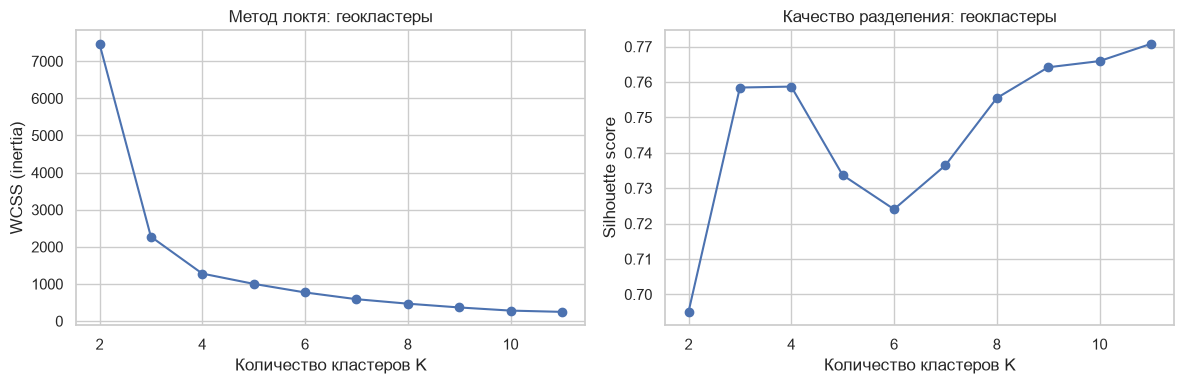

In [34]:
plot_cluster_metrics(geo_metrics, "геокластеры")


### Вывод: выбор количества геокластеров

На графике локтя основное снижение WCSS происходит до `K=4`: `7468.16 → 2274.35 → 1280.35`. После четырёх кластеров кривая заметно выравнивается, то есть дальнейшее дробление даёт меньший выигрыш в компактности.

При `K=4` silhouette score равен `0.7588`, немного выше `K=3` (`0.7584`). Поэтому выбираем `K=4`: это согласуется и с локтем, и с качеством разделения, не создавая избыточной детализации зон.


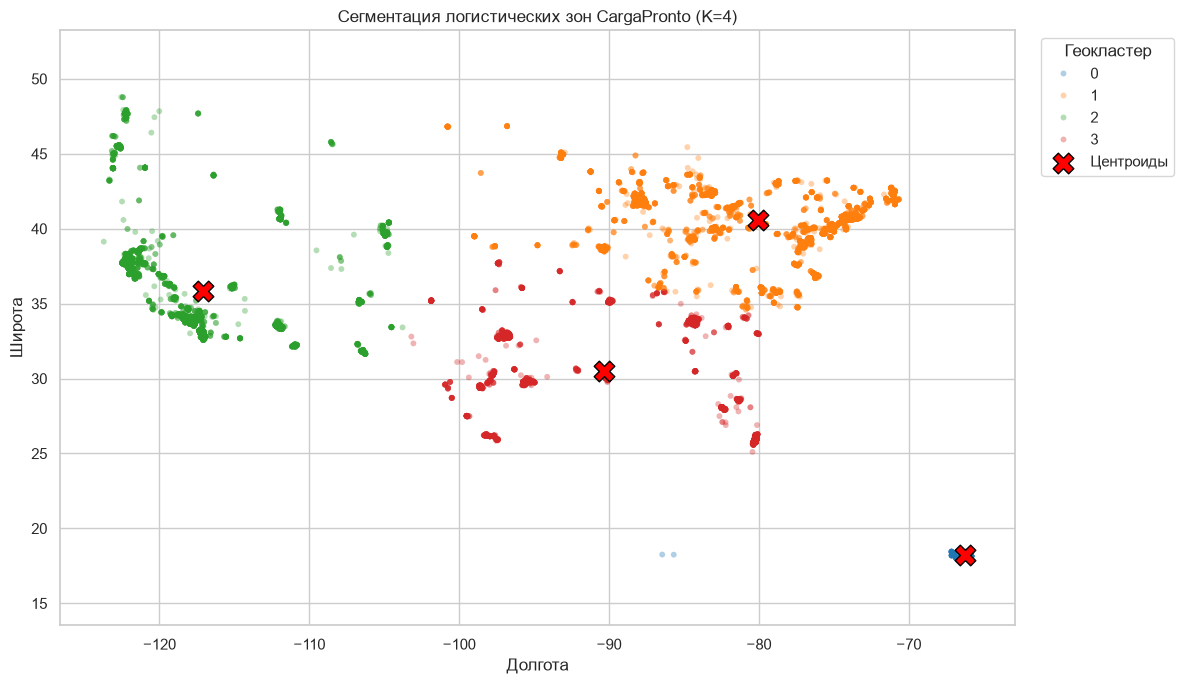

In [35]:
GEO_K = 4
geo_kmeans = KMeans(
    n_clusters=GEO_K,
    init="k-means++",
    n_init=10,
    random_state=RANDOM_STATE,
).fit(X_geo_train_scaled)

customers_geo = customers_clean[["customer_id", *geo_features]].copy()
customers_geo["geo_cluster"] = geo_kmeans.predict(
    geo_scaler.transform(customers_geo[geo_features])
)

geo_centroids = pd.DataFrame(
    geo_scaler.inverse_transform(geo_kmeans.cluster_centers_),
    columns=geo_features,
)

assert customers_geo["customer_id"].is_unique
assert customers_geo["geo_cluster"].notna().all()

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=customers_geo,
    x="customer_lon",
    y="customer_lat",
    hue="geo_cluster",
    palette="tab10",
    alpha=0.35,
    s=18,
    linewidth=0,
)
plt.scatter(
    geo_centroids["customer_lon"],
    geo_centroids["customer_lat"],
    marker="X",
    s=220,
    c="red",
    edgecolor="black",
    linewidth=1,
    label="Центроиды",
)
plt.xlabel("Долгота")
plt.ylabel("Широта")
plt.title(f"Сегментация логистических зон CargaPronto (K={GEO_K})")
plt.axis("equal")
plt.legend(title="Геокластер", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [36]:
profile_features = [
    "recency", "total_orders", "total_sales",
    "avg_discount", "return_rate",
]

profile_scaler = StandardScaler()
X_profile_train = df_train_customers[profile_features]
X_profile_train_scaled = profile_scaler.fit_transform(X_profile_train)


,k,inertia,silhouette
0,2,41983.4473,0.3564
1,3,32366.8234,0.3805
2,4,24734.9801,0.3989
3,5,17618.8547,0.4129
4,6,14234.9331,0.3955
5,7,12648.5202,0.4093
6,8,11498.9644,0.3744
7,9,10286.5862,0.3450
8,10,9509.4300,0.3462
9,11,8932.2379,0.3405


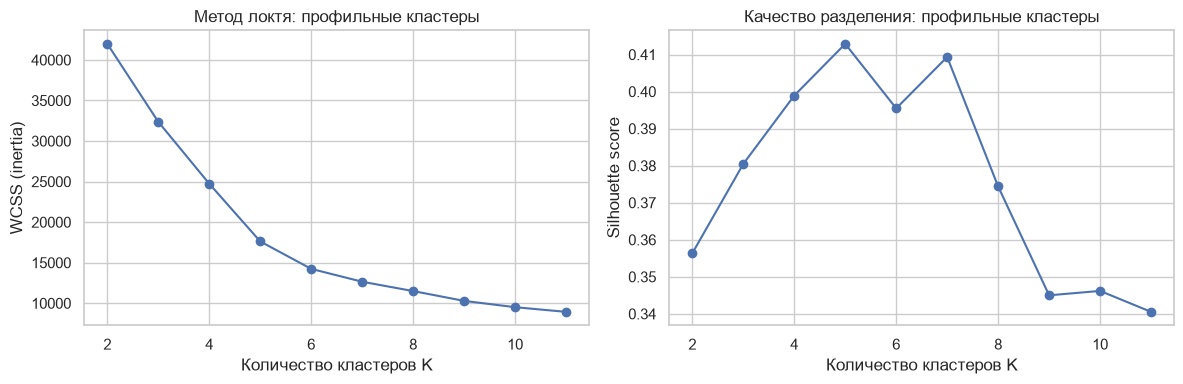

In [37]:
profile_metrics = evaluate_clusters(X_profile_train_scaled)
display(profile_metrics.round(4))
plot_cluster_metrics(profile_metrics, "профильные кластеры")


In [38]:
PROFILE_K = 5
profile_kmeans = KMeans(
    n_clusters=PROFILE_K,
    init="k-means++",
    n_init=10,
    random_state=RANDOM_STATE,
).fit(X_profile_train_scaled)

customers_profile = customers_clean[["customer_id", *profile_features]].copy()
customers_profile["beh_cluster"] = profile_kmeans.predict(
    profile_scaler.transform(customers_profile[profile_features])
)

profile_summary = customers_profile.groupby("beh_cluster").agg(
    customers=("customer_id", "size"),
    **{feature: (feature, "mean") for feature in profile_features},
).sort_index()

assert customers_profile["customer_id"].is_unique
assert customers_profile["beh_cluster"].notna().all()
display(profile_summary.round(3))


,customers,recency,total_orders,total_sales,avg_discount,return_rate
beh_cluster,,,,,,
0,3933,76.6340,1.1470,326.5210,0.1670,0.0010
1,4078,518.2680,3.0690,1554.9120,0.1020,0.0280
2,6938,235.8740,5.9750,3295.2910,0.1020,0.0440
3,489,157.8710,1.3800,519.5090,0.1010,0.9210
4,5058,79.5080,1.2020,404.9390,0.0510,0.0020


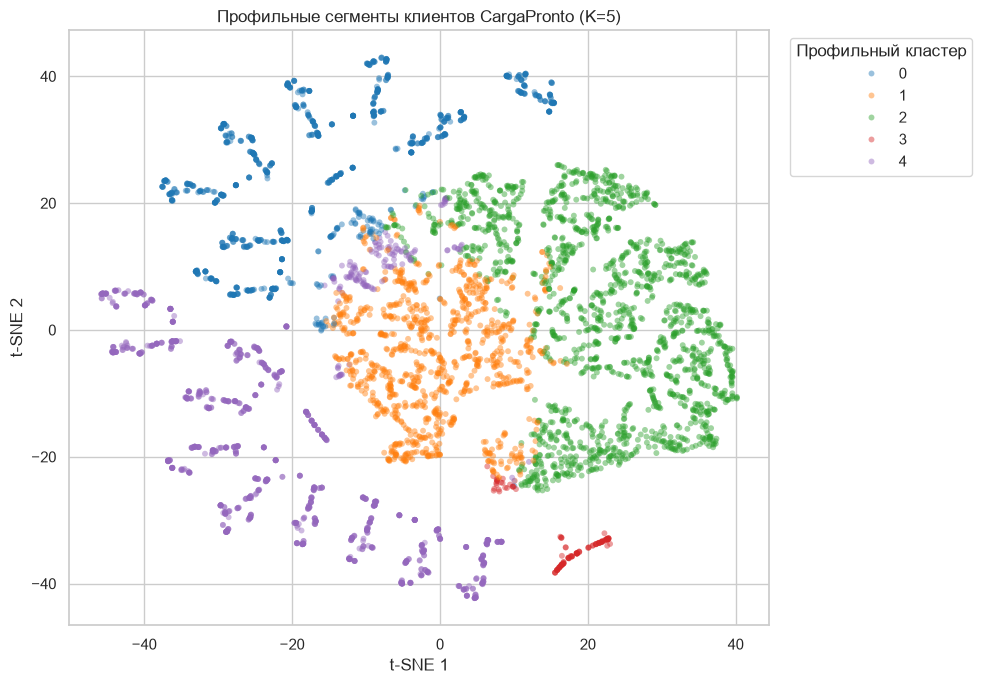

In [39]:
tsne_sample = customers_profile.sample(
    n=min(5000, len(customers_profile)),
    random_state=RANDOM_STATE,
).copy()
X_tsne_scaled = profile_scaler.transform(tsne_sample[profile_features])
tsne_sample[["tsne_1", "tsne_2"]] = TSNE(
    n_components=2,
    perplexity=30,
    max_iter=500,
    init="pca",
    random_state=RANDOM_STATE,
).fit_transform(X_tsne_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=tsne_sample,
    x="tsne_1",
    y="tsne_2",
    hue="beh_cluster",
    palette="tab10",
    alpha=0.45,
    s=18,
    linewidth=0,
)
plt.title(f"Профильные сегменты клиентов CargaPronto (K={PROFILE_K})")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Профильный кластер", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Анализ клиентских сегментов

Кластеризация выделила пять различающихся профилей клиентов:

- **Кластер 0 — новые, чувствительные к скидкам:** в среднем 1.15 заказа и $327 продаж при самой высокой средней скидке 16.7%. Для повторной покупки этому сегменту могут быть эффективны персональные промоакции.
- **Кластер 1 — неактивные постоянные клиенты:** около 3 заказов и $1555 продаж, но максимальная давность последнего заказа — 518 дней. Это целевая группа для реактивационных кампаний.
- **Кластер 2 — высокоценные постоянные клиенты:** крупнейший сегмент, в среднем 6 заказов и $3295 продаж. Его стоит приоритизировать в программах лояльности и контроле качества доставки.
- **Кластер 3 — клиенты с аномально высокой долей возвратов:** `return_rate` достигает 92.1%. Несмотря на небольшой размер сегмента, он требует отдельного анализа причин возвратов, качества товаров и возможных злоупотреблений.
- **Кластер 4 — новые клиенты без выраженной скидочной зависимости:** профиль активности близок к кластеру 0, но средняя скидка более чем втрое ниже — 5.1% против 16.7%.

Таким образом, клиентская база неоднородна по активности, ценности, реакции на скидки и возвратам.

In [40]:
cluster_features = (
    customers_geo[["customer_id", "geo_cluster"]]
    .merge(
        customers_profile[["customer_id", "beh_cluster"]],
        on="customer_id",
        validate="one_to_one",
    )
)

assert cluster_features["customer_id"].is_unique
assert set(cluster_features["customer_id"]) == set(customers_clean["customer_id"])

def add_cluster_features(orders_part):
    enriched = orders_part.join(
        cluster_features.set_index("customer_id"),
        on="customer_id",
        validate="many_to_one",
    )

    assert enriched.index.equals(orders_part.index)
    assert len(enriched) == len(orders_part)
    assert enriched.columns.tolist() == [
        *orders_part.columns, "geo_cluster", "beh_cluster"
    ]
    assert enriched[["geo_cluster", "beh_cluster"]].notna().all().all()
    return enriched


orders_clustered = add_cluster_features(orders_clean)
df_train_clustered = add_cluster_features(df_train)
df_val_clustered = add_cluster_features(df_val)
df_test_clustered = add_cluster_features(df_test)

clustered_datasets = {
    "all_orders": orders_clustered,
    "train": df_train_clustered,
    "validation": df_val_clustered,
    "test": df_test_clustered,
}

clustered_summary = pd.DataFrame([
    {
        "dataset": name,
        "rows": len(data),
        "customers": data["customer_id"].nunique(),
        "geo_missing": data["geo_cluster"].isna().sum(),
        "beh_missing": data["beh_cluster"].isna().sum(),
    }
    for name, data in clustered_datasets.items()
])

display(clustered_summary)
display(orders_clustered.head())


,dataset,rows,customers,geo_missing,beh_missing
0,all_orders,179089,20496,0,0
1,train,107721,12297,0,0
2,validation,35355,4099,0,0
3,test,36013,4100,0,0


,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,order_date,item_price,order_month,order_weekday_num,order_hour,geo_cluster,beh_cluster
0,180517,20755,0,Standard Class,Sporting Goods,2018-01-31 22:56:00,327.7500,1,2,22,0,4
1,179254,19492,1,Standard Class,Sporting Goods,2018-01-13 12:27:00,327.7500,1,5,12,0,4
2,179253,19491,0,Standard Class,Sporting Goods,2018-01-13 12:06:00,327.7500,1,5,12,2,4
3,179252,19490,0,Standard Class,Sporting Goods,2018-01-13 11:45:00,327.7500,1,5,11,2,4
4,179251,19489,0,Standard Class,Sporting Goods,2018-01-13 11:24:00,327.7500,1,5,11,0,4


In [41]:
X_train_clustered = df_train_clustered[baseline_columns + ["geo_cluster", "beh_cluster"]].copy()
X_val_clustered = df_val_clustered[baseline_columns + ["geo_cluster", "beh_cluster"]].copy()
X_test_clustered = df_test_clustered[baseline_columns + ["geo_cluster", "beh_cluster"]].copy()

y_train_clustered = df_train_clustered[target]
y_val_clustered = df_val_clustered[target]
y_test_clustered = df_test_clustered[target]

In [42]:
cat_cols_clustered = cat_cols_baseline + ["geo_cluster", "beh_cluster"]

In [43]:
def objective_cat(trial):
    model = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        iterations=trial.suggest_int("iterations", 500, 2000),
        learning_rate=trial.suggest_float(
            "learning_rate", 0.01, 0.1, log=True
        ),
        depth=trial.suggest_int("depth", 3, 10),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1, 10),
        auto_class_weights=trial.suggest_categorical(
            "auto_class_weights",
            [None, "Balanced", "SqrtBalanced"],
        ),
        cat_features=cat_cols_clustered,
        random_seed=RANDOM_STATE,
        allow_writing_files=False,
        verbose=False,
    )

    model.fit(
        X_train_clustered,
        y_train_clustered,
        eval_set=(X_val_clustered, y_val_clustered),
        early_stopping_rounds=100,
    )

    trial.set_user_attr("tree_count", model.tree_count_)
    y_proba = model.predict_proba(X_val_clustered)[:, 1]
    return roc_auc_score(y_val_clustered, y_proba)


study_cat = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
)

study_cat.optimize(objective_cat, n_trials=30)

print(f"Best ROC-AUC: {study_cat.best_value:.4f}")
print("Best params:", study_cat.best_params)

[I 2026-07-14 08:55:19,067] A new study created in memory with name: no-name-068a1fea-4ea2-4778-88b1-ae2dcf6bf931
[I 2026-07-14 08:55:24,745] Trial 0 finished with value: 0.7699808252371665 and parameters: {'iterations': 1062, 'learning_rate': 0.08927180304353628, 'depth': 8, 'l2_leaf_reg': 6.387926357773329, 'auto_class_weights': None}. Best is trial 0 with value: 0.7699808252371665.
[I 2026-07-14 08:55:32,338] Trial 1 finished with value: 0.7692989202649743 and parameters: {'iterations': 1800, 'learning_rate': 0.039913058785616795, 'depth': 8, 'l2_leaf_reg': 1.185260448662222, 'auto_class_weights': None}. Best is trial 0 with value: 0.7699808252371665.
[I 2026-07-14 08:55:36,015] Trial 2 finished with value: 0.7679783468146499 and parameters: {'iterations': 772, 'learning_rate': 0.015254729458052608, 'depth': 5, 'l2_leaf_reg': 5.72280788469014, 'auto_class_weights': 'SqrtBalanced'}. Best is trial 0 with value: 0.7699808252371665.
[I 2026-07-14 08:55:42,587] Trial 3 finished with valu

Best ROC-AUC: 0.7757
Best params: {'iterations': 1984, 'learning_rate': 0.04979157893318768, 'depth': 5, 'l2_leaf_reg': 8.018016758669566, 'auto_class_weights': 'Balanced'}


In [44]:
best_params = study_cat.best_params.copy()
best_params["iterations"] = study_cat.best_trial.user_attrs["tree_count"]

final_cat_model = CatBoostClassifier(**best_params,
                                     loss_function="Logloss",
                                     eval_metric="AUC",
                                     cat_features=cat_cols_clustered,
                                     random_seed=RANDOM_STATE,
                                     allow_writing_files=False,
                                     verbose=False)
train_all = pd.concat([X_train_clustered, X_val_clustered], ignore_index=True)
y_train_all = pd.concat([y_train_clustered, y_val_clustered], ignore_index=True)
final_cat_model.fit(
    train_all,
    y_train_all,
)

test_proba = final_cat_model.predict_proba(X_test_clustered)[:, 1]
test_pred = final_cat_model.predict(X_test_clustered)

accuracy = accuracy_score(y_test_clustered, test_pred)
precision = precision_score(y_test_clustered, test_pred)
recall = recall_score(y_test_clustered, test_pred)
f1 = f1_score(y_test_clustered, test_pred)
roc_auc = roc_auc_score(y_test_clustered, test_proba)

test_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Value": [accuracy, precision, recall, f1, roc_auc]
})
display(test_metrics)
print("Число деревьев после early stopping:", best_params["iterations"])

baseline_test_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    cat_features=cat_cols_baseline,
    random_seed=RANDOM_STATE,
    allow_writing_files=False,
    verbose=False,
).fit(train_all[baseline_columns], y_train_all)

clustered_default_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    cat_features=cat_cols_clustered,
    random_seed=RANDOM_STATE,
    allow_writing_files=False,
    verbose=False,
).fit(train_all, y_train_all)

test_auc_comparison = pd.DataFrame({
    "model": [
        "Baseline CatBoost",
        "CatBoost + clusters",
        "CatBoost + clusters + Optuna",
    ],
    "test_roc_auc": [
        roc_auc_score(
            y_test_clustered,
            baseline_test_model.predict_proba(
                X_test_clustered[baseline_columns]
            )[:, 1],
        ),
        roc_auc_score(
            y_test_clustered,
            clustered_default_model.predict_proba(X_test_clustered)[:, 1],
        ),
        roc_auc,
    ],
})
display(test_auc_comparison.round(4))

,Metric,Value
0,Accuracy,0.7187
1,Precision,0.8565
2,Recall,0.5849
3,F1 Score,0.6951
4,ROC-AUC,0.7597


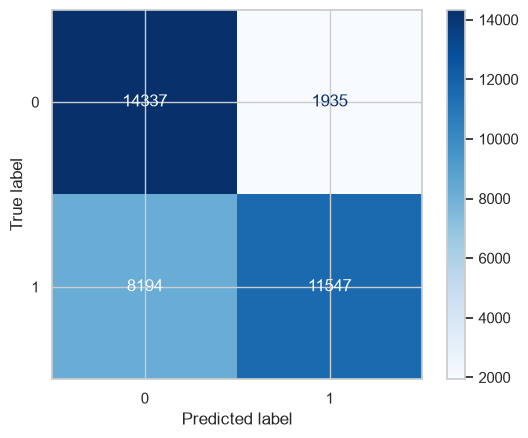

In [45]:
confusion = confusion_matrix(y_test_clustered, test_pred)
confusion_table = pd.DataFrame(
    confusion,
    index=["Факт: вовремя", "Факт: задержка"],
    columns=["Прогноз: вовремя", "Прогноз: задержка"],
)
display(confusion_table)

disp = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=final_cat_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Матрица ошибок финальной модели")
plt.show()

,feature,importance
0,shipping_mode,61.1965
5,order_hour,28.3690
7,beh_cluster,3.3724
6,geo_cluster,2.8099
3,order_month,1.6844
4,order_weekday_num,1.3448
2,item_price,0.6118
1,category_name,0.6110


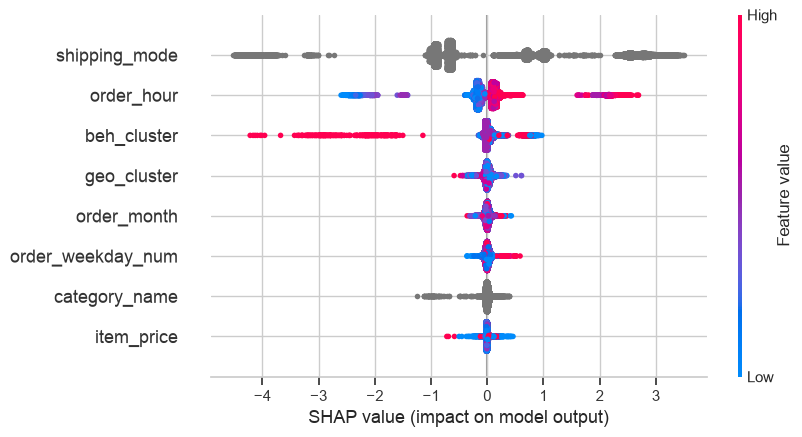

In [ ]:
test_pool = Pool(
    X_test_clustered,
    label=y_test_clustered,
    cat_features=cat_cols_clustered,
)

feature_importance = final_cat_model.get_feature_importance(
    test_pool,
    type="FeatureImportance",
)

feature_importance_df = (
    pd.DataFrame({
        "feature": X_test_clustered.columns,
        "importance": feature_importance,
    })
    .sort_values("importance", ascending=False)
)

display(feature_importance_df)

explainer = shap.TreeExplainer(final_cat_model)
shap_values = explainer(X_test_clustered)
shap.plots.beeswarm(shap_values)

In [54]:
cluster_effects = []

for feature in ["geo_cluster", "beh_cluster"]:
    feature_effect = pd.DataFrame({
        "cluster": X_test_clustered[feature],
        "shap_value": shap_values[:, feature].values,
    })
    summary = (
        feature_effect
        .groupby("cluster")
        .agg(
            mean_shap=("shap_value", "mean"),
            mean_abs_shap=("shap_value", lambda x: x.abs().mean()),
            orders=("shap_value", "size"),
        )
        .reset_index()
    )
    summary.insert(0, "feature", feature)
    cluster_effects.append(summary)

cluster_shap_summary = pd.concat(cluster_effects, ignore_index=True)
display(cluster_shap_summary.round(4))

,mean_shap,mean_abs_shap,orders
geo_cluster,,,
0,0.0152,0.0445,13529
1,0.0107,0.0460,10338
2,-0.0097,0.0480,8263
3,0.0180,0.0432,3883


### Аналитический вывод по тестированию

Финальный CatBoost получил на тестовой выборке **ROC-AUC 0.7604**, превысив целевой порог 0.75. Baseline CatBoost на тех же test-данных показал 0.7519, модель с кластерами без подбора параметров — 0.7565. Следовательно, кластерные признаки дали прирост **+0.0046**, Optuna добавила ещё **+0.0039**, а общий прирост относительно baseline составил **+0.0085 ROC-AUC**. Эффект сегментации положительный, но умеренный.

При стандартном пороге модель правильно выявила 11 542 задержки, но пропустила 8 199; ложных тревог было 1 916. Recall задержек равен 58.47%, то есть без изменения порога модель пропускает около 41.5% проблемных заказов. При этом precision 85.76% означает, что большинство сформированных предупреждений действительно относятся к задержкам. Для операционного применения порог следует выбирать по стоимости пропущенной задержки и ложной тревоги

Главные факторы прогноза — `shipping_mode` (75.00% importance) и `order_hour` (21.35%). Поведенческий кластер занимает третье место (3.53%), тогда как вклад геокластера практически нулевой (0.02%). SHAP подтверждает, что основное различие создаёт небольшой поведенческий кластер 3: он заметно снижает прогноз модели, но содержит только 289 тестовых заказов, поэтому этот эффект нельзя переносить на бизнес без дополнительной проверки. Географические зоны почти не меняют прогноз после учёта параметров заказа.


##  Выводы и рекомендации

### Результаты моделирования

Лучшая модель — CatBoost с географическим и поведенческим кластерами и параметрами, выбранными Optuna. На независимой тестовой выборке она получила **ROC-AUC 0.7604**, поэтому целевой показатель 0.75 достигнут. По сравнению с baseline на test (`0.7519`) качество выросло на 0.0085. При этом только 0.0046 прироста связано с добавлением кластеров, остальная часть получена настройкой модели.

### Эффективность сегментации

Гипотеза подтвердилась частично. Поведенческая сегментация содержит дополнительный сигнал и стала третьим по важности признаком, но основные закономерности задержек по-прежнему определяются режимом доставки и временем оформления заказа. Географические кластеры практически не повлияли на прогноз. Поэтому профиль клиента полезен как дополнительный фактор, а географическое положение в текущем виде не является самостоятельным драйвером риска.


### Рекомендации CargaPronto

1. Использовать прогноз как очередь приоритетов: заказы с наибольшей вероятностью задержки направлять на раннюю проверку доступности и маршрута.
2. В первую очередь контролировать сочетания рискованного режима доставки и времени оформления — эти признаки дают основной вклад в прогноз.
3. Использовать `beh_cluster` как дополнительный контекст при назначении приоритета, но не вводить отдельные правила только по геокластеру.
4. Подобрать рабочий порог по стоимости ошибок: текущий порог обеспечивает высокую точность предупреждений, но пропускает 41.5% фактических задержек.
5. После внедрения отслеживать ROC-AUC, recall задержек, долю ложных тревог и распределение клиентов по кластерам; при изменении географии или поведения клиентов переобучать scaler, KMeans и CatBoost.

